# Ride the AI build-out by buying the datacenter basket? 🖥️
### The "don't pick the winner, buy the picks-and-shovels" trade, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ride_the_build--out%3F: Busted](https://img.shields.io/badge/Ride_the_build--out%3F-Busted-8b949e?style=flat-square)

Here's the pitch you've probably heard: you don't have to guess *which* AI company wins — just buy the **datacenter-and-power basket**. The chips (NVDA), the cooling and electrical gear (VRT, ETN), the utilities that sell the electricity an AI datacenter guzzles (CEG, VST), the AI servers (SMCI, DELL), the network switches (ANET). Own the whole **build-out** and ride the capex wave.

And on the tape it *worked* — this eight-name basket roughly **5×'d** while the market barely doubled. So is "buy the build-out" a real, repeatable strategy? Or is it the oldest trick in finance: **naming the winners after they already won?** This notebook pulls those two apart.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the random-basket distribution and the selection placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A note up front.** Both the basket *and* the wider field we compare it against are **today's** names projected back in time — so they're tilted toward survivors by construction. That bias is the whole point, and we name it on the Signal axis. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ai_datacenter_basket import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS, BENCH = data.load_real(allow_lookahead_selection=True)   # look-ahead is the SUBJECT
    RACE = st.race(RETS, BENCH, data.BASKET, k=8, n_draws=2000, cost_bps=10.0,
                   allow_lookahead_selection=True)
else:
    RETS = BENCH = RACE = None
print("real datacenter panel cache present:", HAVE_REAL,
      "| field names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2022-02', 'end': '2026-05', 'months': 52, 'years': 4.3, 'n_field': 30, 'fp': '7d69ca333d53', 'legs': {'basket': (71.7, 1.65, -21.7), 'spy': (14.3, 0.91, -20.2), 'qqq': (18.5, 0.91, -26.1), 'field': (38.8, 1.55, -16.7), 'expost': (83.7, 1.78, -20.3)}, 'basket_net': 71.5, 't_spy': (47.1, 3.19, 52), 't_qqq': (42.5, 3.12, 52), 't_eqf': (26.0, 2.37, 52), 'basket_spread': 57.4, 'expost_spread': 69.4, 'selection_share': 121, 'pctile': 100.0, 'rand_mean': 23.8, 'rand_median': 23.6, 'expost_members': ['VRT', 'MU', 'SMCI', 'NVDA', 'AVGO', 'DELL', 'VST', 'PWR'], 'names': [('VRT', 69.4, 2.59), ('ANET', 31.9, 2.38), ('CEG', 38.3, 2.18), ('NVDA', 48.2, 2.17), ('VST', 43.4, 2.04), ('SMCI', 84.6, 1.67), ('DELL', 48.9, 1.51), ('ETN', 12.5, 1.27)], 'syn': [(0.0, 4.5, 1.71, 14.3), (0.012, 17.5, 5.77, 21.0)]}


real datacenter panel cache present: True | field names: 30


## The answer first

| Question | Answer |
|---|---|
| Did the basket beat the market? | **Yes, hugely — ~72%/yr vs ~14% for the S&P.** That part is real on the tape (and it even beats the tech-heavy Nasdaq). |
| So it's a great strategy? | **Careful.** The eight are *named because they won*. Pick the eight best-performing names of the field **in hindsight** and you reproduce — even *exceed* — the basket's edge. |
| Could I have picked these eight in 2019? | **No.** A *blindly* chosen eight from the same datacenter/power field already beat the S&P by ~24%/yr — because the **field itself** was on fire. The basket just hand-picks the top of it. |
| Is the build-out real, then? | **The build-out is real. The *basket* is hindsight.** AI capex is genuinely enormous — but that doesn't make *this* eight-name list something you could have specified in advance. |

> The AI build-out is real; the basket that "captures" it is a list of yesterday's winners. A real theme, harvested by hindsight.

## 1 · The claim

> *"Forget stock-picking the one AI champion. The AI boom has to run through physical stuff — GPUs, servers, switches, cooling, and an enormous amount of **electricity**. So buy the **datacenter-and-power basket** — NVDA, VRT, ETN, CEG, VST, SMCI, ANET, DELL — equal-weight, and ride the entire build-out."*

It's the **"sell shovels in a gold rush"** heuristic, updated for AI. And the story has real bones: hyperscaler capex guidance is gigantic and the datacenter power-demand narrative is genuinely documented. The seductive leap is from *"AI capex is huge"* to *"**this specific eight-name list** is how you harvest it"* — a leap that only looks obvious **after** these eight have already re-rated.

## 2 · So what?

Two very different things hide inside "buy the build-out," and only one of them is a strategy. (1) *Did these names go up?* Obviously — that's why they're on the list. The question that matters is (2) *could you have **named** them in advance, and would picking "AI-build-out names" **forward** pay the way the backtest does?* A basket that beats the market only because it's assembled from the realised winners isn't an edge — it's a **scoreboard read backwards**. And a theme can be 100% real (AI capex **is** booming) while *this particular eight-name bet* is pure look-ahead.

## 3 · How would we even know?

We need a fair fight. So we build a **whole candidate field** — every plausible "datacenter-and-power" name a 2019 investor might have considered: chips, networking, electrical/cooling/industrials, regulated *and* merchant utilities, datacenter REITs (**30** names kept). Then three tests:

1. **Did the basket really beat the market?** Race the eight, equal-weight, against the S&P (SPY) *and* the Nasdaq-100 (QQQ) — with a proper (autocorrelation-robust) significance test.
2. **Pick the winners in hindsight.** With the whole tape in view, grab the eight *best* names of the field. If that "cheating" rule reproduces the basket's edge, the basket **is** the cheating rule.
3. **Throw darts.** Draw 2,000 *random* eight-name baskets from the same field. Where does the famous basket land in that cloud — and where does a *blind* pick land?

## 4 · The teardown — let's actually look

**First: did it win?** Grow $1 in the basket, the S&P, the Nasdaq-100, and an equal-weight basket of the *whole* datacenter/power field. The basket's line is in a different postal code.

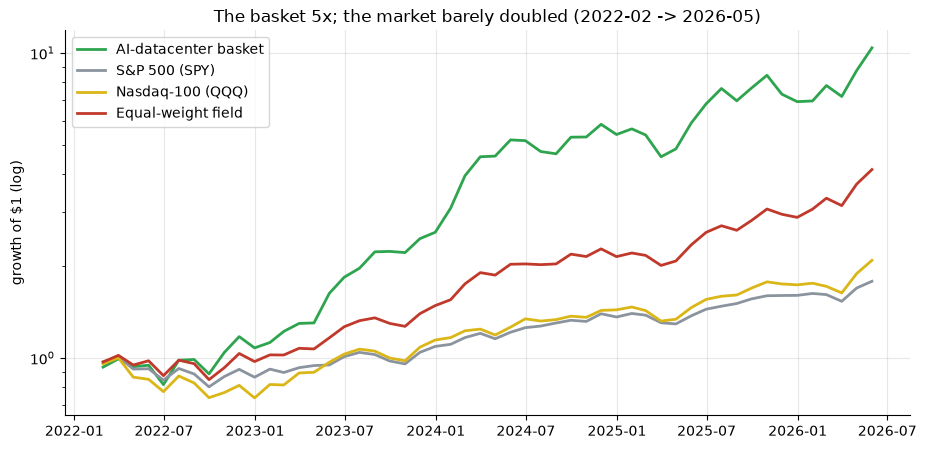

basket CAGR 72%  vs SPY 14%


In [2]:
if HAVE_REAL:
    legs = {'AI-datacenter basket': RACE['basket'], 'S&P 500 (SPY)': RACE['spy'],
            'Nasdaq-100 (QQQ)': RACE['qqq'], 'Equal-weight field': RACE['equal_field']}
    cols = {'AI-datacenter basket': GREEN, 'S&P 500 (SPY)': GREY,
            'Nasdaq-100 (QQQ)': AMBER, 'Equal-weight field': RED}
    fig, ax = plt.subplots(figsize=(9.4, 4.6))
    for name, ser in legs.items():
        eq = (1+ser.dropna()).cumprod()
        ax.plot(eq.index, eq.values, lw=2, c=cols[name], label=name)
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('The basket 5x; the market barely doubled (2022-02 -> 2026-05)')
    ax.legend(); plt.tight_layout(); plt.show()
    print('basket CAGR %.0f%%  vs SPY %.0f%%' % (st.summarize(RACE['basket'])['cagr']*100, st.summarize(RACE['spy'])['cagr']*100))
else:
    names = list(R['legs']); cag = [R['legs'][k][0] for k in names]
    fig, ax = plt.subplots(figsize=(9.0, 4.4))
    ax.bar(names, cag, color=[GREEN, GREY, AMBER, RED, GREEN][:len(names)])
    ax.set_ylabel('CAGR (%)'); ax.set_title('Frozen CAGRs (see docs/results.md)')
    plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()
    print('basket CAGR', R['legs']['basket'][0], '% vs SPY', R['legs']['spy'][0], '%')

On the AI-era tape (**2022-02 → 2026-05**) the basket compounded at **~72%/yr** against the S&P's **~14%** — and it beat the *tech* tape (QQQ, ~18%) too. That out-performance is **real**; it isn't a rounding artefact. So far, so good for the pitch. Now the awkward question: *how was the list chosen?*

**The hindsight test.** Let's *cheat on purpose*: with the entire tape in front of us, pick the eight **best** names of the field. If "pick the winners after the fact" matches the famous basket, the famous basket is just that — winners, named afterward.

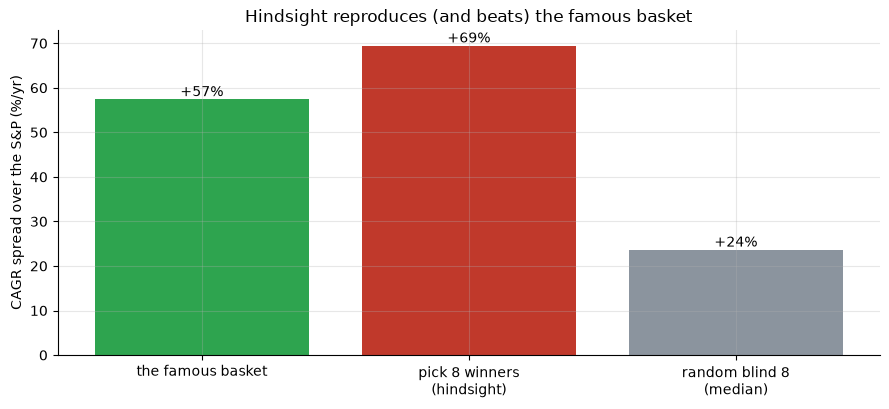

ex-post winners: ['VRT', 'MU', 'SMCI', 'NVDA', 'AVGO', 'DELL', 'VST', 'PWR']


In [3]:
if HAVE_REAL:
    bs = RACE['basket_cagr_spread']*100; es = RACE['expost_cagr_spread']*100
    rs = float(np.median(RACE['rand_spread']))*100
    winners = RACE['expost_members']
else:
    bs, es, rs = R['basket_spread'], R['expost_spread'], R['rand_median']
    winners = R['expost_members']
fig, ax = plt.subplots(figsize=(9.0, 4.2))
bars = ['the famous basket', 'pick 8 winners\n(hindsight)', 'random blind 8\n(median)']
vals = [bs, es, rs]
ax.bar(bars, vals, color=[GREEN, RED, GREY])
for i,v in enumerate(vals): ax.annotate(f'+{v:.0f}%', (i,v), ha='center', va='bottom')
ax.set_ylabel('CAGR spread over the S&P (%/yr)')
ax.set_title('Hindsight reproduces (and beats) the famous basket')
plt.tight_layout(); plt.show()
print('ex-post winners:', winners)

There it is. The hindsight "pick the eight winners" rule beats the S&P by **~69%/yr** — actually **more** than the famous basket's **~57%/yr** (it reproduces **121%** of it). The famous basket is essentially *a slightly-worse version of "the names that won."* And look at the third bar: a **random** eight from the same field already beat the market by **~24%/yr** — because the **field itself** was a furnace.

**The dartboard.** Draw 2,000 random eight-name baskets from the same field. Where does the famous basket sit — and notice where the *whole cloud* sits relative to zero.

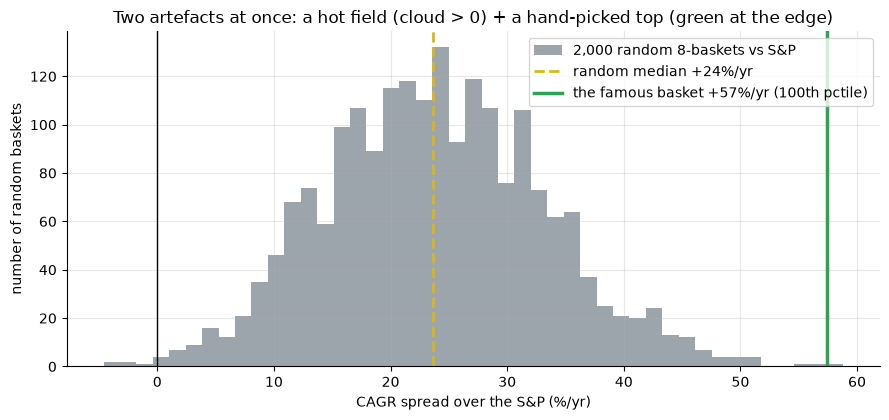

the famous basket sits at the 100th percentile of random baskets from the same field


In [4]:
if HAVE_REAL:
    rand = RACE['rand_spread']*100; basket = RACE['basket_cagr_spread']*100; pct = RACE['basket_pctile']
else:
    rng = np.random.default_rng(393); rand = rng.normal(R['rand_mean'], 18, 2000)
    basket = R['basket_spread']; pct = R['pctile']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand, bins=45, color=GREY, alpha=.85, label='2,000 random 8-baskets vs S&P')
ax.axvline(0, c='k', lw=1)
ax.axvline(np.median(rand), c=AMBER, lw=2, ls='--', label=f'random median +{np.median(rand):.0f}%/yr')
ax.axvline(basket, c=GREEN, lw=2.5, label=f'the famous basket +{basket:.0f}%/yr ({pct:.0f}th pctile)')
ax.set_xlabel('CAGR spread over the S&P (%/yr)'); ax.set_ylabel('number of random baskets')
ax.set_title('Two artefacts at once: a hot field (cloud > 0) + a hand-picked top (green at the edge)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'the famous basket sits at the {pct:.0f}th percentile of random baskets from the same field')

Two things jump out. **(1)** The whole grey cloud sits *well to the right of zero* — even a **random** datacenter/power basket crushed the S&P, because today's field is the set of names that **survived and re-rated** (survivorship). **(2)** The famous basket sits at the very **100th percentile** — the extreme right edge — because it isn't random at all: it's hand-picked from the top. The headline edge is *the field was hot* **plus** *we kept its winners*. Neither is something you could have named in 2019.

## 5 · The verdict

- **Signal — Mixed.** The basket genuinely beat the market and tech on the tape (~72%/yr vs ~14%, and significant) — but it's a **hindsight-selected** list on **one short ~4-year regime**. Real recent spread, look-ahead selection.
- **Tradability — Mirage.** Costs are nothing for an eight-name hold. The mirage is that **you couldn't have named these eight in advance** — and even the "theme" portion is the field's own survivorship, not a tilt you could specify forward.
- **Ride the build-out by buying the basket? — Busted.** The build-out is real; *this basket* is yesterday's scoreboard. It's the same selection trick as the [Magnificent-Seven](../../355-magnificent-seven/) and the [GLP-1 basket](../../356-glp1-basket/).

## 6 · Could you actually trade it? — name it *forward*

The whole game is *when you choose the names*. Compare the thing you could have bought **blindly** (a random eight from the field) against the thing you can only assemble **afterward** (the realised winners). The gap between them is the part of the "edge" that only hindsight can buy.

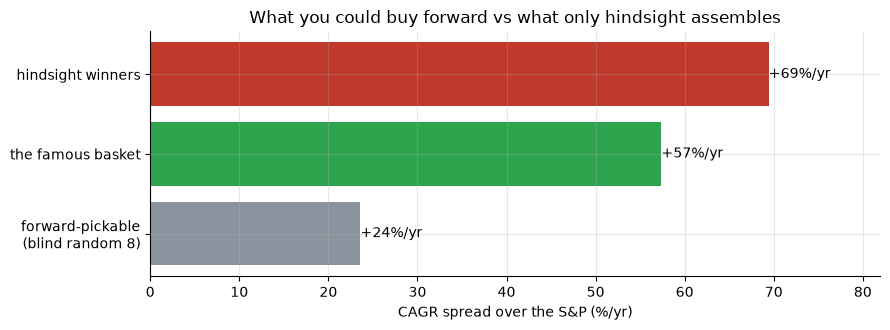

forward-pickable ~+24%/yr  |  hindsight ~+69%/yr  -- the gap is pure selection


In [5]:
if HAVE_REAL:
    blind = float(np.median(RACE['rand_spread']))*100
    hindsight = RACE['expost_cagr_spread']*100
    famous = RACE['basket_cagr_spread']*100
else:
    blind, hindsight, famous = R['rand_median'], R['expost_spread'], R['basket_spread']
fig, ax = plt.subplots(figsize=(9.0, 3.4))
ax.barh(['forward-pickable\n(blind random 8)', 'the famous basket', 'hindsight winners'],
        [blind, famous, hindsight], color=[GREY, GREEN, RED])
for i,v in enumerate([blind, famous, hindsight]): ax.annotate(f'+{v:.0f}%/yr',(v,i),va='center',ha='left')
ax.set_xlabel('CAGR spread over the S&P (%/yr)')
ax.set_title('What you could buy forward vs what only hindsight assembles')
ax.set_xlim(0, hindsight*1.18); plt.tight_layout(); plt.show()
print(f'forward-pickable ~+{blind:.0f}%/yr  |  hindsight ~+{hindsight:.0f}%/yr  -- the gap is pure selection')

The only thing a 2019 investor could actually have done is the **grey** bar — a blind pick from the field — and even that's flattered by survivorship (the field is today's survivors). The **red** bar (~+69%/yr) needs a time machine. The famous basket lives almost entirely in the un-buyable gap between them. Costs never enter the story; **the selection does.**

## 7 · Going further 🚪

- **The mega-cap twin.** [Study 355 — Magnificent-Seven](../../355-magnificent-seven/): the exact same "hold the names that already won" trick on the Mag 7. Read together, the two show that *thematic baskets are scoreboards read backwards*.
- **The single-name cousin.** [Study 356 — GLP-1 basket](../../356-glp1-basket/): a theme basket whose alpha collapses to one stock.
- **The mechanics.** [Study 350 — Dartboard-Portfolio](../../350-dartboard-portfolio/) and [Study 345 — Survivorship-Bias](../../345-survivorship-bias/) show how selection and survivorship manufacture edge from nothing.

*Think "buy the build-out" is forward-tradable? Specify the basket **in advance** — a rule you could have written in 2019 — and show it beats a random pick from the same field out-of-sample. Then we'll talk.*